In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid")

## Gene-level TPM checking

In [10]:
gene_data_K562 = pd.read_csv('/nfs/data/IHEC/RNAseq/RNA-Seq/ihec.rna-seq.ihec-grapenf-containerv1.1.0.IHECRE00001887.4.b2b4ded3-20fb-4626-b1c9-2afcd18bd6ec.genes.results', sep="\t")
gene_data_GM12878 = pd.read_csv('/nfs/data/IHEC/RNAseq/RNA-Seq/ihec.rna-seq.ihec-grapenf-containerv1.1.0.IHECRE00001892.5.c5893651-dcc4-47b1-a647-a853e04e006d.genes.results', sep="\t")

# sanity check
print(f"Summed expression values for K562: {gene_data_K562['TPM'].sum()}")
print(f"Summed expression values for GM12878: {gene_data_GM12878['TPM'].sum()}")

gene_data_GM12878['gene_id'] = gene_data_GM12878['gene_id'].str.split('.').str[0]
gene_data_K562['gene_id'] = gene_data_K562['gene_id'].str.split('.').str[0]

Summed expression values for K562: 999998.9000000001
Summed expression values for GM12878: 999999.2100000001


In [11]:
# get Xpresso TPM values
xpresso_K562 = pd.read_csv('../data/GM12878_K562_18377_gene_expr_fromXpresso.csv', sep=",")
xpresso_GM12878 = pd.read_csv('../data/GM12878_K562_18377_gene_expr_fromXpresso.csv', sep=",")

# filter gene data by gene names present in xpresso data and check their summed TPM
gene_data_K562_filtered = gene_data_K562[gene_data_K562['gene_id'].isin(xpresso_K562['Name'])].copy()
gene_data_GM12878_filtered = gene_data_GM12878[gene_data_GM12878['gene_id'].isin(xpresso_GM12878['Name'])].copy()
print(f"Length of filtered K562 data: {len(gene_data_K562_filtered)} and GM12878 data: {len(gene_data_GM12878_filtered)}")

gene_data_K562_filtered['logTPM'] = np.log10(gene_data_K562_filtered['TPM'] + 0.1)
gene_data_GM12878_filtered['logTPM'] = np.log10(gene_data_GM12878_filtered['TPM'] + 0.1)
# mean center the logTPM values
gene_data_K562_filtered['logTPM_centered'] = gene_data_K562_filtered['logTPM'] - gene_data_K562_filtered['logTPM'].mean()
gene_data_GM12878_filtered['logTPM_centered'] = gene_data_GM12878_filtered['logTPM'] - gene_data_GM12878_filtered['logTPM'].mean()

k562_mean_shift = gene_data_K562_filtered['logTPM'].mean() - xpresso_K562['Actual_K562'].mean()
gm12878_mean_shift = gene_data_GM12878_filtered['logTPM'].mean() - xpresso_GM12878['Actual_GM12878'].mean()
xpresso_K562['TPM'] = (10**(xpresso_K562['Actual_K562'] + k562_mean_shift)) - 0.1
xpresso_GM12878['TPM'] = (10**xpresso_GM12878['Actual_GM12878'] + gm12878_mean_shift) - 0.1

print(f"Summed expression values for K562 from Xpresso: {xpresso_K562['TPM'].sum()} vs. ours {gene_data_K562_filtered['TPM'].sum()}")
print(f"Summed expression values for GM12878 from Xpresso: {xpresso_GM12878['TPM'].sum()} vs. ours {gene_data_GM12878_filtered['TPM'].sum()}")


print(f"Max logTPM for K562: {gene_data_K562_filtered['logTPM_centered'].max()} vs {xpresso_K562['Actual_K562'].max()}")
#print(f"Max logTPM for GM12878: {gene_data_GM12878_filtered['logTPM'].max()} vs {xpresso_GM12878['Actual_GM12878'].max()}")
print(f"Percent values greater than 0 for K562: {np.sum(gene_data_K562_filtered['logTPM_centered'] > 0) / len(gene_data_K562_filtered)} vs " \
      f"{np.sum(xpresso_K562['Actual_K562'] > 0) / len(xpresso_K562)}")

print(f"Expression on subset for K562: {gene_data_K562_filtered['logTPM_centered'].sum()} vs. {xpresso_K562['Actual_K562'].sum()}")
print(f"Expression mean for K562: {gene_data_K562_filtered['logTPM_centered'].mean()} vs. {xpresso_K562['Actual_K562'].mean()}")
#print(f"Expression on subset for GM12878: {gene_data_GM12878_filtered['logTPM'].sum()} vs. {xpresso_GM12878['Actual_GM12878'].sum()}")

Length of filtered K562 data: 18378 and GM12878 data: 18378
Summed expression values for K562 from Xpresso: 336291.21872238285 vs. ours 582995.7300000001
Summed expression values for GM12878 from Xpresso: 151685.1619453938 vs. ours 557859.0099999999
Max logTPM for K562: 3.817631216838529 vs 3.585388929
Percent values greater than 0 for K562: 0.5200239416693873 vs 0.5193992490613266
Expression on subset for K562: -3.410605131648481e-13 vs. 2.1293544705258682e-10
Expression mean for K562: -1.855808647104408e-17 vs. 1.1587062472252643e-14


<Figure size 600x600 with 0 Axes>

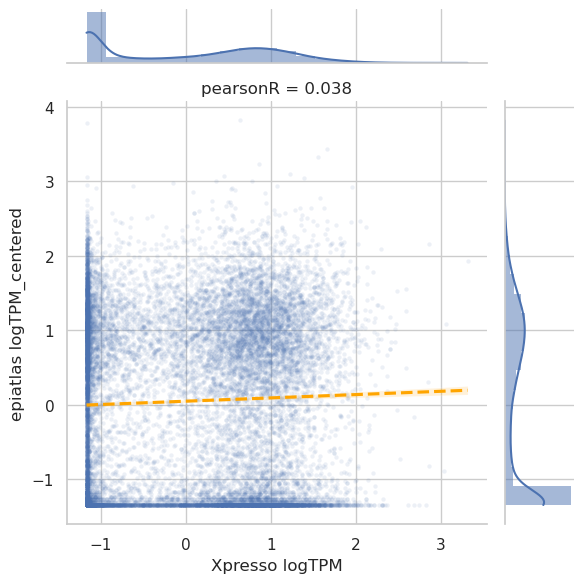

In [12]:
gene_data_k562_combined = pd.DataFrame({
    'gene_id': gene_data_K562_filtered['gene_id'],
    'epiatlas': gene_data_K562_filtered['logTPM_centered'],
    'xpresso': xpresso_K562['Actual_K562']
})
gene_data_k562_combined = gene_data_k562_combined.dropna()

pearson_r = stats.pearsonr(gene_data_k562_combined['epiatlas'], gene_data_k562_combined['xpresso'])
plt.figure(figsize=(6,6))
ax = sns.jointplot(
    data=gene_data_k562_combined,
    x="xpresso",
    y="epiatlas",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
plt.title('pearsonR = {:.3f}'.format(pearson_r.statistic))
plt.ylabel('epiatlas logTPM_centered')
plt.xlabel('Xpresso logTPM')
plt.tight_layout()

## Transcript-level PSI check

In [13]:
transcript_data_K562 = pd.read_csv('/nfs/data/IHEC/RNAseq/RNA-Seq/ihec.rna-seq.ihec-grapenf-containerv1.1.0.IHECRE00001887.4.b2b4ded3-20fb-4626-b1c9-2afcd18bd6ec.isoforms.results', sep="\t")
transcript_data_GM12878 = pd.read_csv('/nfs/data/IHEC/RNAseq/RNA-Seq/ihec.rna-seq.ihec-grapenf-containerv1.1.0.IHECRE00001892.5.c5893651-dcc4-47b1-a647-a853e04e006d.isoforms.results', sep="\t")

transcript_data_K562

,transcript_id,gene_id,length,effective_length,expected_count,TPM,FPKM,IsoPct,posterior_mean_count,posterior_standard_deviation_of_count,pme_TPM,pme_FPKM,IsoPct_from_pme_TPM,TPM_ci_lower_bound,TPM_ci_upper_bound,FPKM_ci_lower_bound,FPKM_ci_upper_bound
0,ENST00000373020.8,ENSG00000000003.14,2206,2030.73,55.41,0.22,0.18,62.87,54.20,1.81,0.22,0.18,56.92,1.608270e-01,0.277850,1.332920e-01,0.230265
1,ENST00000494424.1,ENSG00000000003.14,820,644.74,6.63,0.08,0.07,23.68,4.11,2.34,0.06,0.05,16.59,2.193320e-06,0.137676,1.817170e-06,0.114099
2,ENST00000496771.5,ENSG00000000003.14,1025,849.73,4.96,0.05,0.04,13.45,5.00,0.96,0.06,0.05,14.78,1.466610e-02,0.106528,1.215460e-02,0.088274
3,ENST00000612152.4,ENSG00000000003.14,3796,3620.73,0.00,0.00,0.00,0.00,1.05,1.34,0.00,0.00,1.19,4.863360e-08,0.013262,4.030870e-08,0.010990
4,ENST00000614008.4,ENSG00000000003.14,900,724.73,0.00,0.00,0.00,0.00,2.64,2.26,0.04,0.03,10.52,1.613580e-06,0.103276,1.336960e-06,0.085586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206689,ENST00000649331.1,ENSG00000285990.1,647,471.76,5.03,0.09,0.07,100.00,5.25,2.15,0.11,0.09,100.00,1.271860e-02,0.213360,1.056700e-02,0.176823
206690,ENST00000647612.1,ENSG00000285991.1,5065,4889.73,18.07,0.03,0.02,100.00,21.04,7.62,0.04,0.03,100.00,1.039400e-02,0.065376,8.611500e-03,0.054181
206691,ENST00000648949.1,ENSG00000285992.1,956,780.73,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,100.00,1.945150e-07,0.030284,1.612460e-07,0.025098
206692,ENST00000650266.1,ENSG00000285993.1,1246,1070.73,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,100.00,6.978950e-09,0.022575,5.781390e-09,0.018710


<Figure size 600x600 with 0 Axes>

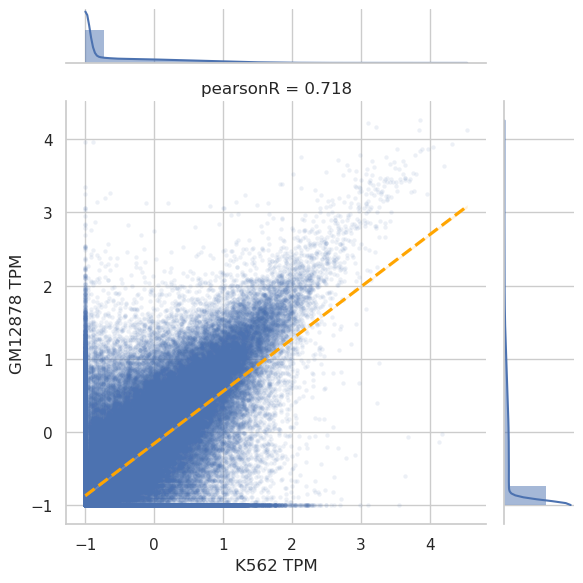

In [14]:
# get boxplot for K562 TPM distribution and GM12878 TPM distribution
transcript_data_GM12878['TPM'] = np.log10(transcript_data_GM12878['TPM'] + 0.1)
transcript_data_K562['TPM'] = np.log10(transcript_data_K562['TPM'] + 0.1)

transcript_data_GM12878['source'] = 'GM12878'
transcript_data_K562['source'] = 'K562'

transcript_data_combined = pd.DataFrame({
    'K562': transcript_data_K562['TPM'],
    'GM12878': transcript_data_GM12878['TPM'],
})

# remove na
transcript_data_combined = transcript_data_combined.dropna(axis=0, how='any')


pearson_r = stats.pearsonr(transcript_data_combined['K562'], transcript_data_combined['GM12878'])
plt.figure(figsize=(6,6))
ax = sns.jointplot(
    data=transcript_data_combined,
    x="K562",
    y="GM12878",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
plt.title('pearsonR = {:.3f}'.format(pearson_r.statistic))
plt.ylabel('GM12878 TPM')
plt.xlabel('K562 TPM')
plt.tight_layout()

In [15]:
se_events = pd.read_csv('../data/transcript_SE.psi', sep="\t", skiprows=1, header=None, names=['event', 'k562_psi', 'gm12878_psi'])

def parse_event(event):
    gene_id, coords = event.split(';')
    event_type, chrom, exon1, exon2, strand = coords.split(':')
    return pd.Series({
        'gene_id': gene_id,
        'event_type': event_type,
        'chrom': chrom,
        'exon1': exon1,
        'exon2': exon2,
        'strand': strand
    })

parsed_events = se_events['event'].apply(parse_event)

se_events = pd.concat([se_events, parsed_events], axis=1)
se_events

FileNotFoundError: [Errno 2] No such file or directory: '../data/transcript_SE.psi'

In [16]:
# print number of events
print("Number of SE events:", se_events.shape[0])
# print number of unique genes
print("Number of unique genes:", se_events['gene_id'].nunique())


# print how many nan values we have in the psi column
print("Number of NaN values in K562 PSI:", se_events['k562_psi'].isna().sum(), "in GM12878 PSI", se_events['gm12878_psi'].isna().sum())
print("Coverage in GM12878 PSI:", se_events['k562_psi'].notna().mean(), "GM12878 PSI:", se_events['gm12878_psi'].notna().mean())

NameError: name 'se_events' is not defined

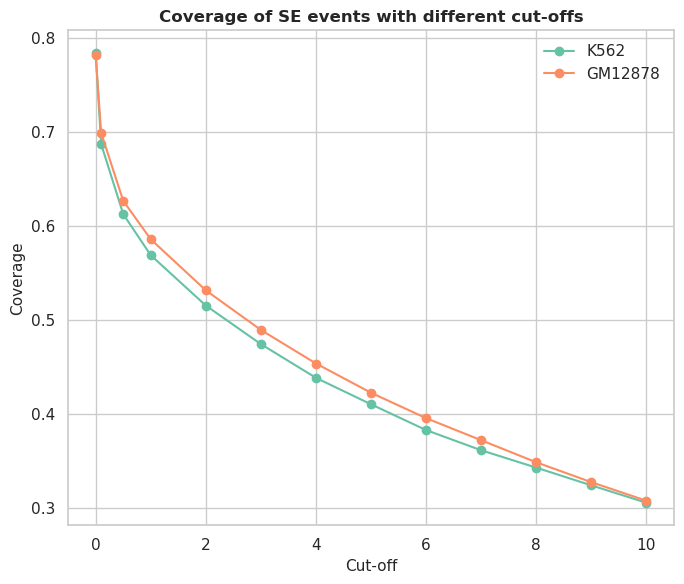

In [18]:
cut_offs = [0, 0.1, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
k562_coverages = []
gm12878_coverages = []

for cut_off in cut_offs:
    cut_se_events = pd.read_csv(f'../data/SE_events_tpm_filtered/transcript_SE_f{cut_off}.psi', sep="\t", skiprows=1, 
                            header=None, names=['event', 'k562_psi', 'gm12878_psi'])
    k_coverage = cut_se_events['k562_psi'].notna().mean()
    gm_coverage = cut_se_events['gm12878_psi'].notna().mean()
    k562_coverages.append(k_coverage)
    gm12878_coverages.append(gm_coverage)

fig, ax = plt.subplots(figsize=(7, 6))

palette = sns.color_palette("Set2", n_colors=2)

ax.plot(cut_offs, k562_coverages, label='K562', marker='o', color=palette[0])
ax.plot(cut_offs, gm12878_coverages, label='GM12878', marker='o', color=palette[1])

ax.set_xlabel('Cut-off', fontsize=11)
ax.set_ylabel('Coverage', fontsize=11)
ax.set_title('Coverage of SE events with different cut-offs', fontsize=12, weight="bold")

ax.legend(title='', loc='best', frameon=False)

plt.tight_layout()
plt.savefig("../images/coverage_cutoffs.png")
plt.show()

<Figure size 600x600 with 0 Axes>

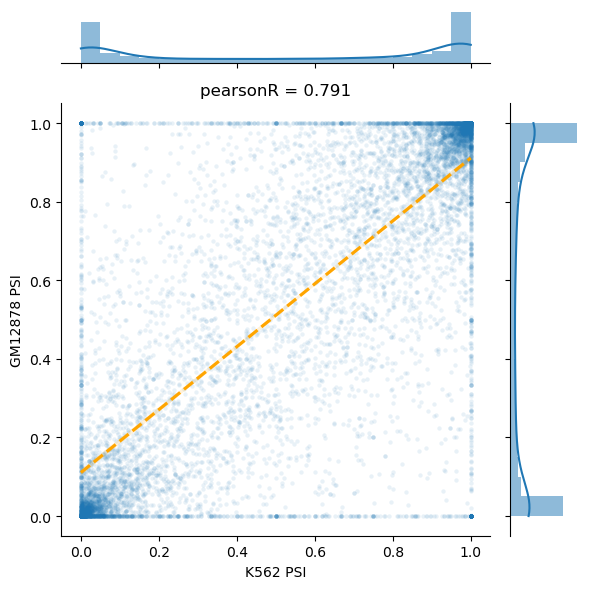

In [ ]:
# drop lines where either gm12878_psi or k562_psi is NaN
combined_psi_values = se_events[['k562_psi', 'gm12878_psi']].dropna(axis=0, how='any')


pearson_r = stats.pearsonr(combined_psi_values['k562_psi'], combined_psi_values['gm12878_psi'])
plt.figure(figsize=(6,6))
ax = sns.jointplot(
    data=combined_psi_values,
    x="k562_psi",
    y="gm12878_psi",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
plt.title('pearsonR = {:.3f}'.format(pearson_r.statistic))
plt.ylabel('GM12878 PSI')
plt.xlabel('K562 PSI')
plt.tight_layout()


In [ ]:
# count how many values are 0, and how many are 1, how many are in between
print("Number of 0 values in K562 PSI:", (se_events_k562['psi'] == 0).sum())
print("Number of 1 values in K562 PSI:", (se_events_k562['psi'] == 1).sum())
print("Number of between 0 and 1 values in K562 PSI:", ((se_events_k562['psi'] > 0) & (se_events_k562['psi'] < 1)).sum())


Number of 0 values in K562 PSI: 4971
Number of 1 values in K562 PSI: 4113
Number of between 0 and 1 values in K562 PSI: 22723


# PSI Response Checking

In [ ]:
psi_response = pd.read_csv('data/psi_response.csv')
psi_response

,gene_id,event_id,K562_summed_tpm,GM12878_summed_tpm,K562_alt_tpm,GM12878_alt_tpm,K562_gene_level_tpm,GM12878_gene_level_tpm,K562_SE_psi,GM12878_SE_psi
0,ENSG00000228794,ENSG00000228794;SE:chr1:829104-847654:847806-8...,0.846337,0.558709,0.739572,0.309630,1.053846,0.892095,0.778902,0.551136
1,ENSG00000224051,ENSG00000224051;SE:chr1:1325102-1326836:132703...,0.499687,1.133219,0.492760,1.120903,0.576341,1.146438,0.983660,0.971831
2,ENSG00000160072,ENSG00000160072;SE:chr1:1486668-1487863:148791...,1.236285,1.539202,1.172019,1.475816,1.344589,1.576687,0.861646,0.863808
3,ENSG00000160072,ENSG00000160072;SE:chr1:1489274-1489692:148981...,1.172019,1.475816,0.611723,0.610660,1.344589,1.576687,0.270325,0.133512
4,ENSG00000197530,ENSG00000197530;SE:chr1:1624901-1624991:162518...,0.220108,0.382017,0.184691,0.359835,0.833147,1.226858,0.916667,0.948052
...,...,...,...,...,...,...,...,...,...,...
7509,ENSG00000071889,ENSG00000071889;SE:chrX:154507490-154507811:15...,1.250908,1.129045,1.177536,1.055760,1.467756,1.265525,0.843679,0.843563
7510,ENSG00000071889,ENSG00000071889;SE:chrX:154511871-154512823:15...,1.091667,1.020361,1.081707,0.988113,1.467756,1.265525,0.977143,0.927746
7511,ENSG00000071889,ENSG00000071889;SE:chrX:154511871-154512314:15...,1.184691,1.080626,0.522444,0.382017,1.467756,1.265525,0.212500,0.193467
7512,ENSG00000130830,ENSG00000130830;SE:chrX:154792285-154799745:15...,2.348324,1.070407,0.453318,-1.000000,2.468805,1.156246,0.012292,0.000000


In [ ]:
# compare for both cell lines summed tpm and gene level tpm
psi_response['TPMDelta_K562'] = abs(psi_response['K562_summed_tpm'] - psi_response['K562_gene_level_tpm'])
psi_response['TPMDelta_GM12878'] = abs(psi_response['GM12878_summed_tpm'] - psi_response['GM12878_gene_level_tpm'])
psi_response['Index'] = psi_response.index

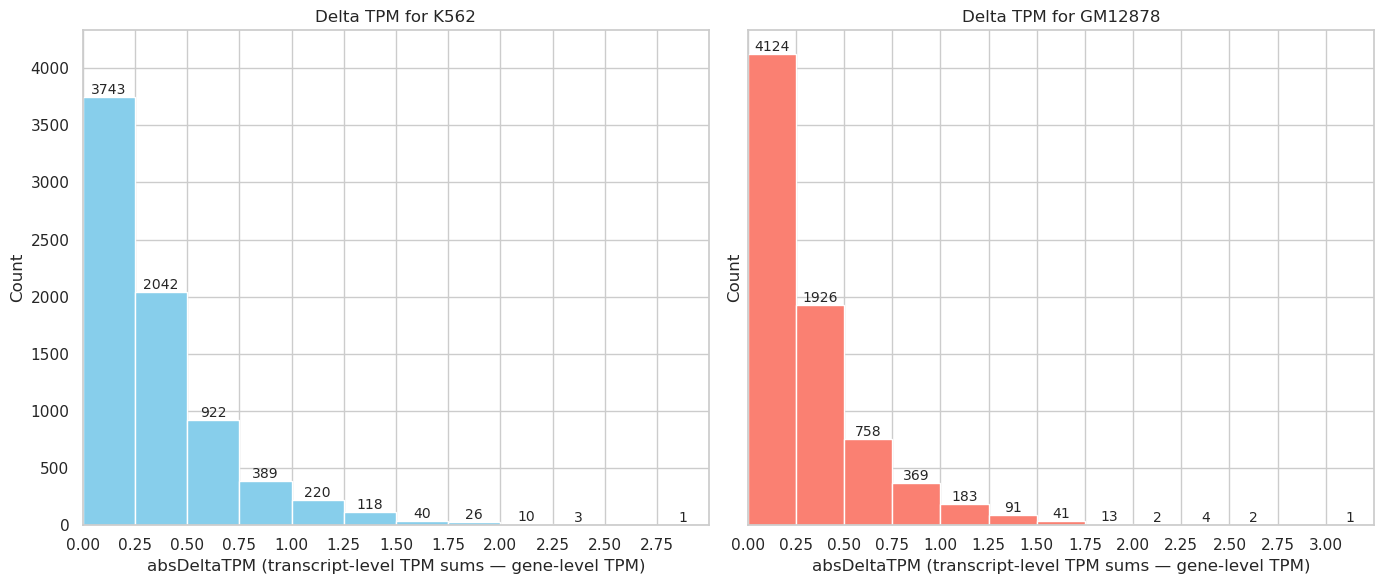

In [ ]:
sns.set(style="whitegrid")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

def plot_hist_with_counts(ax, data, title, color):
    counts, bins, patches = ax.hist(data, bins=np.arange(0, data.max() + 0.25, 0.25), color=color)
    ax.set_title(title)
    ax.set_xlabel('absDeltaTPM (transcript-level TPM sums — gene-level TPM)')
    ax.set_ylabel('Count')
    ax.set_xticks(bins[:-1])
    ax.set_xlim([min(bins), max(bins)])

    # Annotate bars with counts
    for count, patch in zip(counts, patches):
        if count > 0:
            ax.text(patch.get_x() + patch.get_width() / 2, count + 0.1, int(count),
                    ha='center', va='bottom', fontsize=10)

# Plot Delta A-B
plot_hist_with_counts(axes[0], psi_response['TPMDelta_K562'], 'Delta TPM for K562', 'skyblue')

# Plot Delta C-D
plot_hist_with_counts(axes[1], psi_response['TPMDelta_GM12878'], 'Delta TPM for GM12878', 'salmon')

# Layout
plt.tight_layout()
plt.show()
